# Assignment: Supervised Learning

Complete the following exercises using Python.

1. **Linear Regression Exercise** — California Housing dataset
2. **Classification Exercise** — Breast Cancer dataset (Logistic Regression vs KNN)

---

## Exercise 1: Linear Regression — California Housing

Using the California Housing dataset from scikit-learn, create a linear regression model to predict house prices.
Evaluate the performance of Linear Regression on the test set.

**Dataset**: The California Housing dataset contains 8 features (e.g., median income, house age, average rooms) and the target is the **median house value** (in $100,000s) for districts in California.

**Steps**:
1. Load the dataset
2. Explore the data
3. Prepare features and target
4. Split into training (80%) and testing (20%) sets
5. Train a Linear Regression model
6. Evaluate using MSE and R²
7. Visualize actual vs predicted values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
housing = fetch_california_housing()

# Create a DataFrame for easier exploration
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Basic statistics of the dataset
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Feature Correlation with Target

Let's check which features correlate most strongly with median house value.

In [4]:
# Correlation of features with the target variable
correlations = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
print(correlations)

MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64


### Prepare Features and Split Data

We will use all 8 features to train the model (multiple linear regression).

In [5]:
# Prepare features (X) and target (y)
X = df[housing.feature_names]
y = df['MedHouseVal']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size    :", X_test.shape)

Training set size: (16512, 8)
Test set size    : (4128, 8)


### Train the Linear Regression Model

In [6]:
# Create and fit the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Intercept :", lr_model.intercept_)
print("\nCoefficients:")
for name, coef in zip(housing.feature_names, lr_model.coef_):
    print(f"  {name:20s}: {coef:.4f}")

Intercept : -37.02327770606409

Coefficients:
  MedInc              : 0.4487
  HouseAge            : 0.0097
  AveRooms            : -0.1233
  AveBedrms           : 0.7831
  Population          : -0.0000
  AveOccup            : -0.0035
  Latitude            : -0.4198
  Longitude           : -0.4337


### Evaluate Model Performance on Test Set

We use two metrics:
- **Mean Squared Error (MSE)**: Average squared difference between predicted and actual values. Lower is better.
- **R² Score**: Proportion of variance in the target explained by the model. Closer to 1 is better.

In [7]:
# Generate predictions on the test set
y_pred = lr_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score                : {r2:.4f}")

Mean Squared Error (MSE): 0.5559
R² Score                : 0.5758


### Visualise: Actual vs Predicted House Values

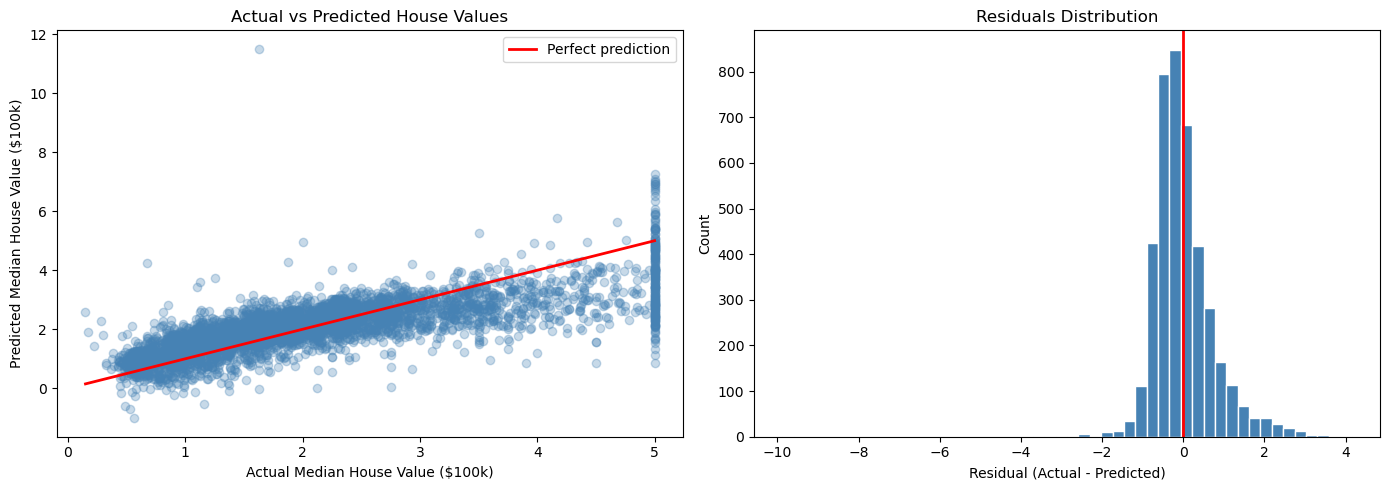


Summary — Linear Regression on California Housing:
  MSE : 0.5559
  R²  : 0.5758

The model explains 57.6% of the variance in house prices.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='red', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Median House Value ($100k)')
axes[0].set_ylabel('Predicted Median House Value ($100k)')
axes[0].set_title('Actual vs Predicted House Values')
axes[0].legend()

# Residuals distribution
residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals Distribution')

plt.tight_layout()
plt.show()

print(f"\nSummary — Linear Regression on California Housing:")
print(f"  MSE : {mse:.4f}")
print(f"  R²  : {r2:.4f}")
print(f"\nThe model explains {r2*100:.1f}% of the variance in house prices.")

---

## Exercise 2: Classification — Breast Cancer (Logistic Regression vs KNN)

Using the breast cancer dataset from scikit-learn, build classification models to predict malignant vs benign tumours.
Compare Logistic Regression and KNN performance on the test set.

**Dataset**: The Breast Cancer Wisconsin dataset contains 30 numeric features computed from a digitised image of a fine needle aspirate (FNA) of a breast mass. The target is binary:
- `0` = Malignant
- `1` = Benign

**Steps**:
1. Load the dataset
2. Explore the data
3. Prepare features and target
4. Split into training (70%) and testing (30%) sets
5. Train Logistic Regression and evaluate
6. Train KNN and evaluate
7. Compare results

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [10]:
# Load dataset
cancer = load_breast_cancer()

# Create a DataFrame for exploration
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer['target'] = cancer.target

print("Shape:", df_cancer.shape)
print("\nClass distribution:")
print(df_cancer['target'].value_counts().rename({0: 'Malignant (0)', 1: 'Benign (1)'}))
df_cancer.head()

Shape: (569, 31)

Class distribution:
target
Benign (1)       357
Malignant (0)    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [11]:
# Basic statistics
df_cancer.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Prepare Features and Split Data

In [12]:
# Prepare features (X) and target (y)
X = df_cancer[cancer.feature_names].values  # convert to numpy array for sklearn compatibility
y = df_cancer['target'].values

# Split into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size    :", X_test.shape)

Training set size: (398, 30)
Test set size    : (171, 30)


### Model 1: Logistic Regression

Logistic Regression models the probability that an instance belongs to the positive class (Benign = 1) using the sigmoid function.

In [13]:
# Train Logistic Regression
lr_clf = LogisticRegression(max_iter=10000, random_state=42)
lr_clf.fit(X_train, y_train)

# Predict and evaluate on test set
y_pred_lr = lr_clf.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression — Accuracy: {acc_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=cancer.target_names))

Logistic Regression — Accuracy: 0.9766

              precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        63
      benign       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



### Model 2: K-Nearest Neighbors (KNN)

KNN classifies a new data point based on the majority class among its `k` nearest neighbours in the training set.

We'll first find the optimal `k` by evaluating accuracy across different `k` values.

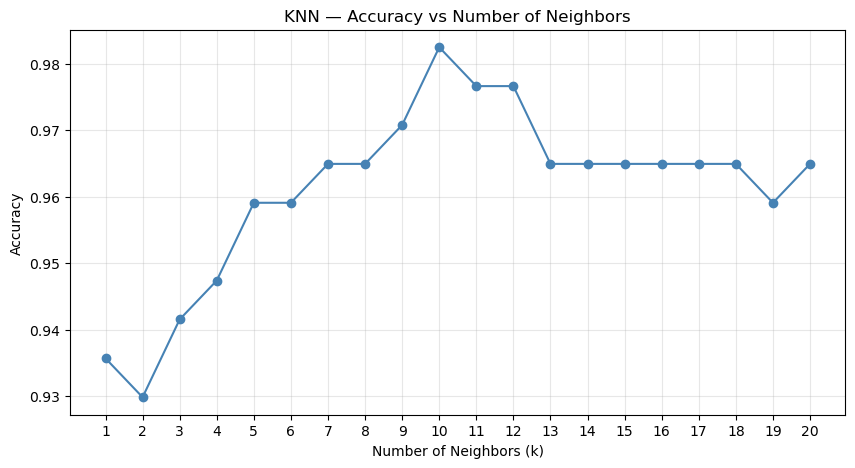

Best k: 10  (Accuracy: 0.9825)


In [14]:
# Find the optimal k by evaluating accuracy for k = 1 to 20
k_range = range(1, 21)
k_accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    k_accuracies.append(accuracy_score(y_test, y_pred_k))

plt.figure(figsize=(10, 5))
plt.plot(k_range, k_accuracies, marker='o', color='steelblue')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN — Accuracy vs Number of Neighbors')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

best_k = k_range[np.argmax(k_accuracies)]
print(f"Best k: {best_k}  (Accuracy: {max(k_accuracies):.4f})")

In [15]:
# Train final KNN model with the best k
knn_clf = KNeighborsClassifier(n_neighbors=best_k)
knn_clf.fit(X_train, y_train)

# Predict and evaluate on test set
y_pred_knn = knn_clf.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN (k={best_k}) — Accuracy: {acc_knn:.4f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=cancer.target_names))

KNN (k=10) — Accuracy: 0.9825

              precision    recall  f1-score   support

   malignant       0.98      0.97      0.98        63
      benign       0.98      0.99      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



### Comparison: Logistic Regression vs KNN

              Model  Accuracy
Logistic Regression  0.976608
         KNN (k=10)  0.982456


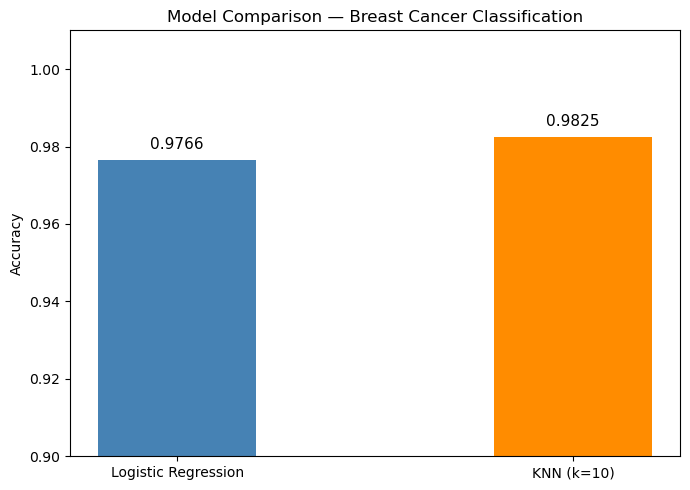

In [16]:
# Summary comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', f'KNN (k={best_k})'],
    'Accuracy': [acc_lr, acc_knn]
})

print(results.to_string(index=False))

# Bar chart comparison
plt.figure(figsize=(7, 5))
colors = ['steelblue', 'darkorange']
bars = plt.bar(results['Model'], results['Accuracy'], color=colors, width=0.4)
for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11)
plt.ylim(0.9, 1.01)
plt.ylabel('Accuracy')
plt.title('Model Comparison — Breast Cancer Classification')
plt.tight_layout()
plt.show()

### Summary

| Model | Accuracy on Test Set |
|---|---|
| Logistic Regression | 0.9766 |
| KNN (k=10) | 0.9825 |

**Observations**:
- Both models perform very well on the breast cancer classification task (>97% accuracy).
- KNN with k=10 slightly outperforms Logistic Regression on this test set.
- Logistic Regression provides a probabilistic interpretation of predictions and tends to be more robust when feature scales differ significantly across features.
- KNN is a non-parametric model that makes no assumptions about the underlying data distribution. Its performance depends heavily on the choice of `k` and can be sensitive to feature scaling — features with larger ranges can dominate distance computations.
- For clinical datasets like breast cancer, it is also important to look beyond accuracy — particularly at **recall for the malignant class (class 0)**, since false negatives (classifying a malignant tumour as benign) are more costly than false positives.